# Import layers

In [1]:

import time
import numpy as np
import seaborn as sns
import sys
from pathlib import Path

from torchvision import datasets

In [2]:

p = Path()
LOCAL_PATH = str(p.cwd())
ROOT_PATH  = str(p.cwd().parent.parent.parent)
LAYER_PATH = str(p.cwd().parent.parent)
info = """LOCAL_PATH: '{}'
ROOT_PATH : '{}'
LAYER_PATH: '{}'
""".format(LOCAL_PATH, ROOT_PATH, LAYER_PATH)
print(info)

# add:
sys.path.append(LAYER_PATH)
sys.path.append(ROOT_PATH)

from sys_function import *

LOCAL_PATH: '/home/gheorghe/Desktop/Proiecte/master/CARN/deep_learning/dataset/test'
ROOT_PATH : '/home/gheorghe/Desktop/Proiecte/master/CARN'
LAYER_PATH: '/home/gheorghe/Desktop/Proiecte/master/CARN/deep_learning'



In [15]:

sys_remove_modules("dataset", "add_virtual_dataset")

from dataset.add_virtual_dataset import *

## Data aquisition

In [4]:

dataset_path = "{}/data_visualisation/data".format(ROOT_PATH)

cifar10_train = datasets.CIFAR10(root=dataset_path, train=True, transform=None, download=True)
print(str(cifar10_train))
cifar10_test = datasets.CIFAR10(root=dataset_path, train=False, transform=None, download=True)
print(str(cifar10_test))

Files already downloaded and verified
Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
    Split: Train
Files already downloaded and verified
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
    Split: Test


In [5]:

oxfordIIIPet_train = datasets.OxfordIIITPet(root=dataset_path, split="trainval", 
                             target_types="category", 
                             transform=None, download=True)
oxfordIIIPet_test  = datasets.OxfordIIITPet(root=dataset_path, split="test", 
                             target_types="category", 
                             transform=None, download=True)

print(str(oxfordIIIPet_train))
print(str(oxfordIIIPet_test))

Dataset OxfordIIITPet
    Number of datapoints: 3680
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
Dataset OxfordIIITPet
    Number of datapoints: 3669
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data


# Test

In [6]:
AddVirtualDatasets.help()

meta_ds: 'dict', main dataset
   data_reader - 'object' that has '__getitem__' method return tuple (input, target)
   size        - 'int' size of all dataset
   num_classes - 'int' number of classes
help_metads: 'dict' of meta_ds, where key is name of dataset and value is meta_ds
transform  : 'tranforms' or function to transform input
help_from  : 'float' percent from size of main dataset, equal distributed for all help dataset
   ex: size main dataset = 100, help_from = 0.1; total size of help dataset is 110, 10 is distributed for all help dataset
   


In [8]:

main_ds = dict(data_reader=cifar10_train, size=50000, num_classes=10)
ds_man = AddVirtualDatasets(main_ds, help_metads=None, transform=None, help_from=0.1)
print(ds_man)

AddVirtualDatasets:
   size: 50000,
   num_classes : 10,
   virtual size: 0,
   size per help dataset: 0,
   
name: main,
   data_reader: Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
    Split: Train, 
   dataset size: 50000,
   


target 1


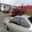

In [13]:
input, target = ds_man[50000-1]
print("target {}".format(target))
input

In [16]:

cf_test_ds     = dict(data_reader=cifar10_test, size=10000, num_classes=10)
oxford_test_ds = dict(data_reader=oxfordIIIPet_test, size=3669, num_classes=37)

help_metads = dict(cifar10_test=cf_test_ds, oxfordIIIPet_test=oxford_test_ds)

ds_man = AddVirtualDatasets(main_ds, help_metads=help_metads, transform=None, help_from=0.1)
print(ds_man)

AddVirtualDatasets:
   size: 55000,
   num_classes : 10,
   virtual size: 5000,
   size per help dataset: 2500,
   
name: main,
   data_reader: Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
    Split: Train, 
   dataset size: 50000,
   
name: cifar10_test,
   data_reader: Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
    Split: Test, 
   dataset size: 10000,
   
name: oxfordIIIPet_test,
   data_reader: Dataset OxfordIIITPet
    Number of datapoints: 3669
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data, 
   dataset size: 3669,
   


target 7


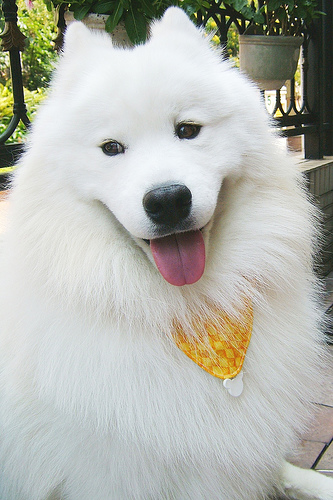

In [24]:

input, target = ds_man[55000-3]
print("target {}".format(target))
input